<a href="https://colab.research.google.com/github/Nandinigarg117/Loan-Approval-Prediction-System/blob/main/hdfcbankaimodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Step 1 — Import Libraries

In [ ]:
Gcolab link- https://colab.research.google.com/drive/1I6JClNOPOZ_LBp9oXUOj-6rB2IVxcp16?usp=sharing


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Pipeline & Preprocessing
from sklearn.pipeline            import Pipeline
from sklearn.compose             import ColumnTransformer
from sklearn.impute              import SimpleImputer
from sklearn.preprocessing       import OrdinalEncoder, StandardScaler

# Models
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.model_selection     import cross_val_score, StratifiedKFold
from sklearn.metrics             import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc,
    f1_score, precision_score, recall_score,
    precision_recall_curve
)

HDFC_BLUE  = '#003087'
HDFC_RED   = '#D32F2F'
HDFC_GREEN = '#2E7D32'
HDFC_ORG   = '#FF6F00'
sns.set_theme(style='whitegrid', font_scale=1.1)
%matplotlib inline
plt.rcParams['figure.dpi'] = 110


##  Step 2 — Load Data

In [ ]:
train_df = pd.read_csv("train_dataset_augmented.csv")
test_df  = pd.read_csv("test_dataset.csv")

print(f'Train: {train_df.shape}  |  Test: {test_df.shape}')
print(f'Test has Loan_Status: {"Loan_Status" in test_df.columns}')
train_df.head()

Train: (3500, 13)  |  Test: (367, 12)
Test has Loan_Status: False


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP000001,Male,No,0,Graduate,Yes,1829,0.00,216.0,360.0,0.0,Semiurban,N
1,LP000002,Female,Yes,3+,Graduate,No,7540,0.00,118.0,360.0,1.0,Urban,Y
2,LP000003,Male,No,3+,Graduate,No,10356,763.96,137.0,360.0,1.0,Urban,Y
3,LP000004,Male,No,3+,Graduate,No,2128,2099.07,178.0,360.0,1.0,Semiurban,Y
4,LP000005,Male,Yes,2,Not Graduate,No,7667,0.00,185.0,360.0,NaN,Rural,Y


In [ ]:
info_df = pd.DataFrame({
    'Data Type'    : train_df.dtypes,
    'Missing Count': train_df.isnull().sum(),
    'Missing %'    : (train_df.isnull().sum() / len(train_df) * 100).round(2)
})
print(' Train Dataset Info:')
display(info_df)
train_df.describe()

 Train Dataset Info:


,Data Type,Missing Count,Missing %
Loan_ID,object,0,0.00
Gender,object,63,1.80
Married,object,19,0.54
Dependents,object,93,2.66
Education,object,0,0.00
Self_Employed,object,176,5.03
ApplicantIncome,int64,0,0.00
CoapplicantIncome,float64,0,0.00
LoanAmount,float64,117,3.34
Loan_Amount_Term,float64,83,2.37


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,3500.000000,3500.000000,3383.000000,3417.000000,3197.000000
mean,6086.912286,1825.901634,150.756429,341.682177,0.844855
std,4560.394221,2018.860604,73.314971,63.812543,0.362100
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2029.250000,0.000000,93.000000,360.000000,1.000000
50%,4781.000000,1448.080000,142.000000,360.000000,1.000000
75%,8995.250000,3097.987500,198.000000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


##  Step 3 — Exploratory Data Analysis

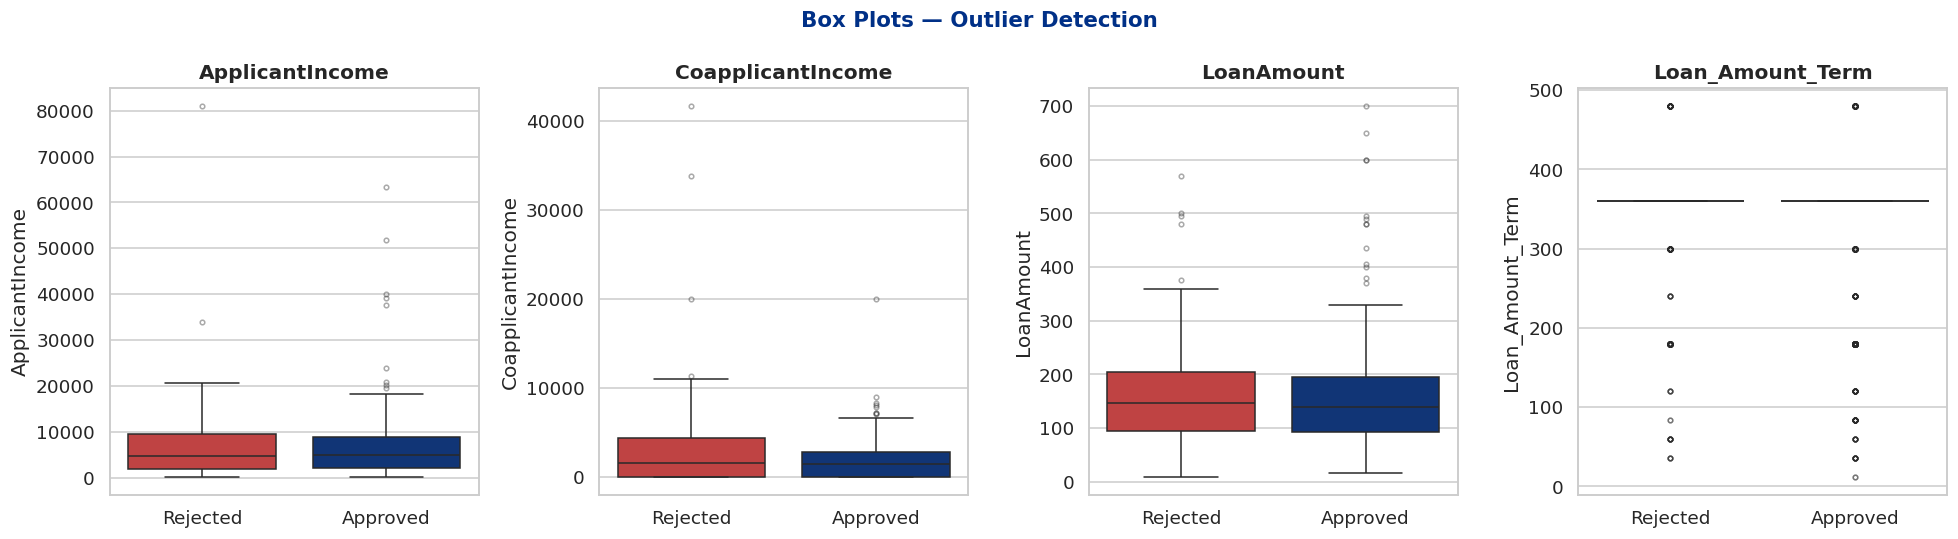

In [ ]:
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
fig, axes = plt.subplots(1, 4, figsize=(18,5))
fig.suptitle('Box Plots — Outlier Detection', fontsize=14, fontweight='bold', color=HDFC_BLUE)
for i, col in enumerate(num_cols):
    tmp = train_df[[col,'Loan_Status']].dropna()
    tmp['Status'] = tmp['Loan_Status'].map({'Y':'Approved','N':'Rejected'})
    sns.boxplot(data=tmp, x='Status', y=col, palette=[HDFC_RED,HDFC_BLUE], ax=axes[i],
                flierprops=dict(marker='o',markersize=3,alpha=0.4))
    axes[i].set_title(col, fontweight='bold'); axes[i].set_xlabel('')
plt.tight_layout(); plt.show()

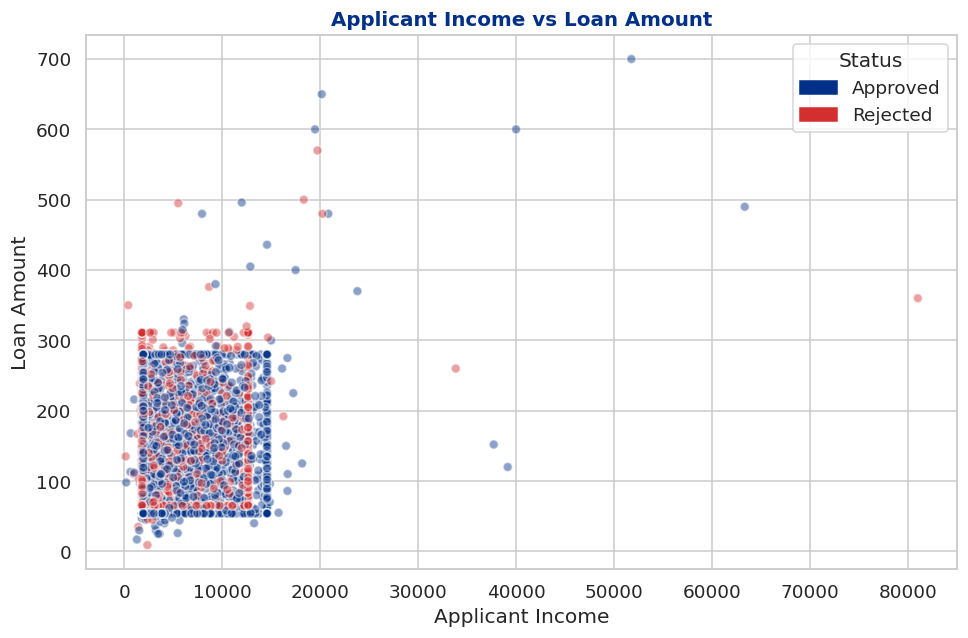

In [ ]:
fig, ax = plt.subplots(figsize=(9,6))
colors = train_df['Loan_Status'].map({'Y':HDFC_BLUE,'N':HDFC_RED})
ax.scatter(train_df['ApplicantIncome'], train_df['LoanAmount'],
           c=colors, alpha=0.45, edgecolors='white', s=35)
ax.legend(handles=[mpatches.Patch(color=HDFC_BLUE,label='Approved'),
                   mpatches.Patch(color=HDFC_RED,label='Rejected')], title='Status')
ax.set_title('Applicant Income vs Loan Amount', fontsize=13, fontweight='bold', color=HDFC_BLUE)
ax.set_xlabel('Applicant Income'); ax.set_ylabel('Loan Amount')
plt.tight_layout(); plt.show()

In [ ]:
#Outlier Removal
cols_to_clean = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

for col in cols_to_clean:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    train_df[col] = train_df[col].clip(lower=lower, upper=upper)

print(" Outliers capped successfully!")
print(train_df[cols_to_clean].describe())

 Outliers capped successfully!
       ApplicantIncome  CoapplicantIncome   LoanAmount
count      3500.000000         3500.00000  3383.000000
mean       6024.195857         1799.15325   150.013450
std        4097.819402         1772.54161    70.143068
min         150.000000            0.00000     9.000000
25%        2029.250000            0.00000    93.000000
50%        4781.000000         1448.08000   142.000000
75%        8995.250000         3097.98750   198.000000
max       19444.250000         7744.96875   355.500000


###  Step 4 — Preprocessing Pipelines

In [ ]:
# Save Loan_ID for final predictions output
test_loan_ids = test_df['Loan_ID'].copy()

# Separate target and drop ID
train_df['Loan_Status'] = train_df['Loan_Status'].map({'Y':1,'N':0})
X_train = train_df.drop(['Loan_ID','Loan_Status'], axis=1)
y_train = train_df['Loan_Status']
X_test  = test_df.drop('Loan_ID', axis=1)

print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_test :', X_test.shape)

# ── Define feature groups ─────────────────────────────────────────────────────
numerical_features   = ['ApplicantIncome','CoapplicantIncome','LoanAmount',
                         'Loan_Amount_Term','Credit_History']
categorical_features = ['Gender','Married','Dependents','Education',
                         'Self_Employed','Property_Area']

# ── Numerical Pipeline: Impute → Scale ────────────────────────────────────────
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# ── Categorical Pipeline: Impute → Encode ─────────────────────────────────────
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# ── ColumnTransformer: combine both pipelines ─────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline,   numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

print('\n✅ Preprocessing Pipelines defined!')
print('   Numerical  :', numerical_features)
print('   Categorical:', categorical_features)

X_train: (3500, 11) | y_train: (3500,)
X_test : (367, 11)

✅ Preprocessing Pipelines defined!
   Numerical  : ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
   Categorical: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


### Correlation Heatmap (after encoding inside pipeline)

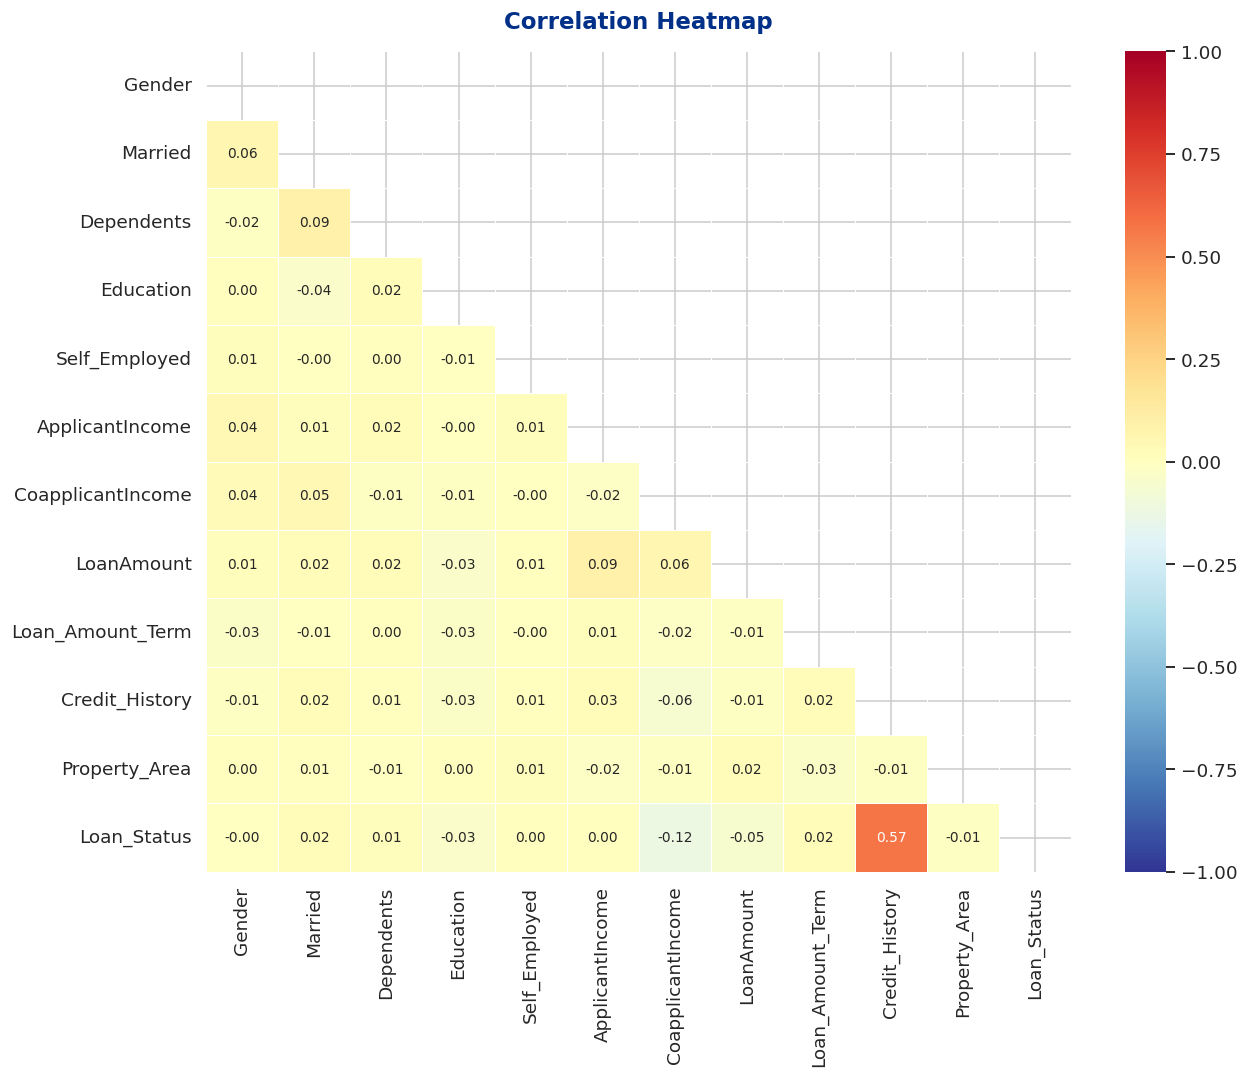

In [ ]:
# Quick preview correlation on train (encode categoricals temporarily for heatmap)
from sklearn.preprocessing import LabelEncoder
tmp = train_df.drop('Loan_ID', axis=1, errors='ignore').copy()
for col in tmp.select_dtypes('object').columns:
    tmp[col] = LabelEncoder().fit_transform(tmp[col].astype(str))

fig, ax = plt.subplots(figsize=(12,10))
mask = np.triu(np.ones_like(tmp.corr(), dtype=bool))
sns.heatmap(tmp.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            vmin=-1, vmax=1, linewidths=0.5, linecolor='white', ax=ax, annot_kws={'size':9})
ax.set_title('Correlation Heatmap', fontsize=15, fontweight='bold', color=HDFC_BLUE, pad=15)
plt.tight_layout(); plt.show()

---
##  Model 1 — Logistic Regression Pipeline
`

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Full Pipeline = Preprocessor + Model
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=42))
])

pipe_lr.fit(X_train, y_train)

# Predictions on training data
y_pred_lr = pipe_lr.predict(X_train)
y_prob_lr = pipe_lr.predict_proba(X_train)[:, 1]

# Metrics
acc_lr = accuracy_score(y_train, y_pred_lr)
f1_lr  = f1_score(y_train, y_pred_lr)

# Cross-validation
cv_acc_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='accuracy')
cv_auc_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='roc_auc')
cv_f1_lr  = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')

fpr_lr, tpr_lr, _ = roc_curve(y_train, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

print('═'*58)
print('  🔵 LOGISTIC REGRESSION PIPELINE')
print('═'*58)
print(f'  Train Accuracy     : {acc_lr*100:.2f}%')
print(f'  Train F1 Score     : {f1_lr:.4f}')
print(f'  Train AUC          : {auc_lr:.4f}')
print(f'  CV Accuracy (5-Fold): {cv_acc_lr.mean()*100:.2f}% ± {cv_acc_lr.std()*100:.2f}%')
print(f'  CV AUC    (5-Fold) : {cv_auc_lr.mean():.4f} ± {cv_auc_lr.std():.4f}')
print(f'  CV F1     (5-Fold) : {cv_f1_lr.mean():.4f} ± {cv_f1_lr.std():.4f}')
print()
print(classification_report(y_train, y_pred_lr, target_names=['Rejected','Approved']))

══════════════════════════════════════════════════════════
  🔵 LOGISTIC REGRESSION PIPELINE
══════════════════════════════════════════════════════════
  Train Accuracy     : 81.37%
  Train F1 Score     : 0.8799
  Train AUC          : 0.7474
  CV Accuracy (5-Fold): 81.37% ± 1.11%
  CV AUC    (5-Fold) : 0.7369 ± 0.0144
  CV F1     (5-Fold) : 0.8800 ± 0.0065

              precision    recall  f1-score   support

    Rejected       0.92      0.43      0.58      1073
    Approved       0.80      0.98      0.88      2427

    accuracy                           0.81      3500
   macro avg       0.86      0.71      0.73      3500
weighted avg       0.83      0.81      0.79      3500



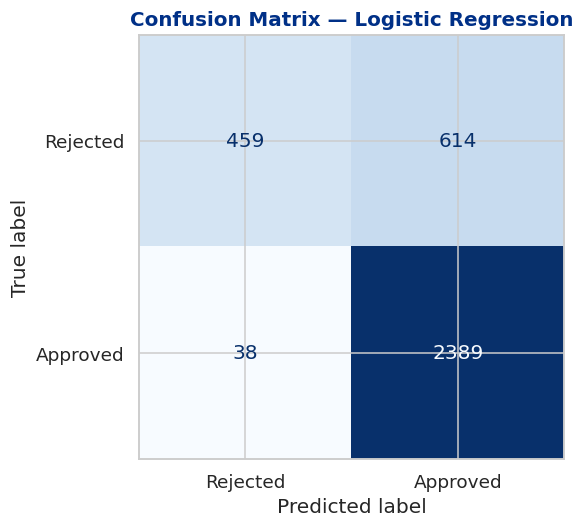

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_lr),
                       display_labels=['Rejected','Approved']).plot(
    ax=ax, colorbar=False, cmap=plt.cm.Blues)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold', color=HDFC_BLUE)
plt.tight_layout(); plt.show()

---
##  Model 2 — Random Forest Pipeline


In [ ]:
from sklearn.compose import ColumnTransformer

# RF doesn't need scaling — use a separate preprocessor without StandardScaler
preprocessor_tree = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), numerical_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), categorical_features)
])

pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier',   RandomForestClassifier(n_estimators=100,
    max_depth=10,          # ← limit tree depth
    min_samples_split=10,  # ← need 10 samples to split
    min_samples_leaf=5,    # ← need 5 samples at leaf
    max_features='sqrt',   # ← use subset of features
    random_state=42))
])

pipe_rf.fit(X_train, y_train)

y_pred_rf = pipe_rf.predict(X_train)
y_prob_rf = pipe_rf.predict_proba(X_train)[:, 1]

acc_rf = accuracy_score(y_train, y_pred_rf)
f1_rf  = f1_score(y_train, y_pred_rf)


cv_acc_rf = cross_val_score(pipe_rf, X_train, y_train, cv=cv, scoring='accuracy')
cv_auc_rf = cross_val_score(pipe_rf, X_train, y_train, cv=cv, scoring='roc_auc')
cv_f1_rf  = cross_val_score(pipe_rf, X_train, y_train, cv=cv, scoring='f1')

fpr_rf, tpr_rf, _ = roc_curve(y_train, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

print('═'*58)
print('  🟢 RANDOM FOREST PIPELINE')
print('═'*58)
print(f'  Train Accuracy     : {acc_rf*100:.2f}%')
print(f'  Train F1 Score     : {f1_rf:.4f}')
print(f'  Train AUC          : {auc_rf:.4f}')
print(f'  CV Accuracy (5-Fold): {cv_acc_rf.mean()*100:.2f}% ± {cv_acc_rf.std()*100:.2f}%')
print(f'  CV AUC    (5-Fold) : {cv_auc_rf.mean():.4f} ± {cv_auc_rf.std():.4f}')
print(f'  CV F1     (5-Fold) : {cv_f1_rf.mean():.4f} ± {cv_f1_rf.std():.4f}')
print()
print(classification_report(y_train, y_pred_rf, target_names=['Rejected','Approved']))

══════════════════════════════════════════════════════════
  🟢 RANDOM FOREST PIPELINE
══════════════════════════════════════════════════════════
  Train Accuracy     : 89.86%
  Train F1 Score     : 0.9309
  Train AUC          : 0.9583
  CV Accuracy (5-Fold): 88.26% ± 1.17%
  CV AUC    (5-Fold) : 0.9225 ± 0.0160
  CV F1     (5-Fold) : 0.9199 ± 0.0077

              precision    recall  f1-score   support

    Rejected       0.95      0.70      0.81      1073
    Approved       0.88      0.98      0.93      2427

    accuracy                           0.90      3500
   macro avg       0.92      0.84      0.87      3500
weighted avg       0.90      0.90      0.89      3500



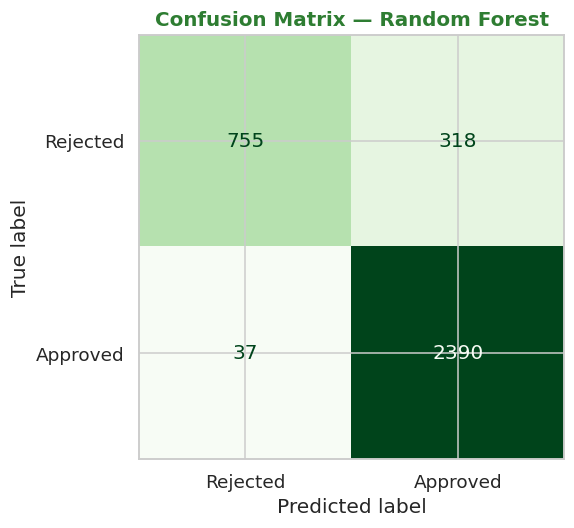

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_rf),
                       display_labels=['Rejected','Approved']).plot(
    ax=ax, colorbar=False, cmap=plt.cm.Greens)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold', color=HDFC_GREEN)
plt.tight_layout(); plt.show()

---
##  Model 3 — Gradient Boosting Pipeline


In [ ]:
pipe_gb = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier',   GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42))
])

pipe_gb.fit(X_train, y_train)

y_pred_gb = pipe_gb.predict(X_train)
y_prob_gb = pipe_gb.predict_proba(X_train)[:, 1]

acc_gb = accuracy_score(y_train, y_pred_gb)
f1_gb  = f1_score(y_train, y_pred_gb)


cv_acc_gb = cross_val_score(pipe_gb, X_train, y_train, cv=cv, scoring='accuracy')
cv_auc_gb = cross_val_score(pipe_gb, X_train, y_train, cv=cv, scoring='roc_auc')
cv_f1_gb  = cross_val_score(pipe_gb, X_train, y_train, cv=cv, scoring='f1')

fpr_gb, tpr_gb, _ = roc_curve(y_train, y_prob_gb)
auc_gb = auc(fpr_gb, tpr_gb)

print('═'*58)
print('  🟠 GRADIENT BOOSTING PIPELINE')
print('═'*58)
print(f'  Train Accuracy     : {acc_gb*100:.2f}%')
print(f'  Train F1 Score     : {f1_gb:.4f}')
print(f'  Train AUC          : {auc_gb:.4f}')
print(f'  CV Accuracy (5-Fold): {cv_acc_gb.mean()*100:.2f}% ± {cv_acc_gb.std()*100:.2f}%')
print(f'  CV AUC    (5-Fold) : {cv_auc_gb.mean():.4f} ± {cv_auc_gb.std():.4f}')
print(f'  CV F1     (5-Fold) : {cv_f1_gb.mean():.4f} ± {cv_f1_gb.std():.4f}')
print()
print(classification_report(y_train, y_pred_gb, target_names=['Rejected','Approved']))

══════════════════════════════════════════════════════════
  🟠 GRADIENT BOOSTING PIPELINE
══════════════════════════════════════════════════════════
  Train Accuracy     : 94.60%
  Train F1 Score     : 0.9623
  Train AUC          : 0.9925
  CV Accuracy (5-Fold): 90.06% ± 1.29%
  CV AUC    (5-Fold) : 0.9313 ± 0.0105
  CV F1     (5-Fold) : 0.9310 ± 0.0088

              precision    recall  f1-score   support

    Rejected       0.99      0.84      0.90      1073
    Approved       0.93      0.99      0.96      2427

    accuracy                           0.95      3500
   macro avg       0.96      0.92      0.93      3500
weighted avg       0.95      0.95      0.94      3500



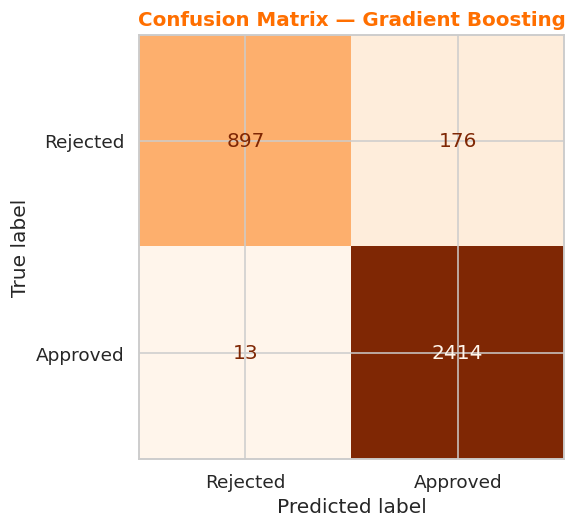

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_gb),
                       display_labels=['Rejected','Approved']).plot(
    ax=ax, colorbar=False, cmap=plt.cm.Oranges)
ax.set_title('Confusion Matrix — Gradient Boosting', fontsize=13, fontweight='bold', color=HDFC_ORG)
plt.tight_layout(); plt.show()

---
##  ROC Curves — All 3 Pipelines

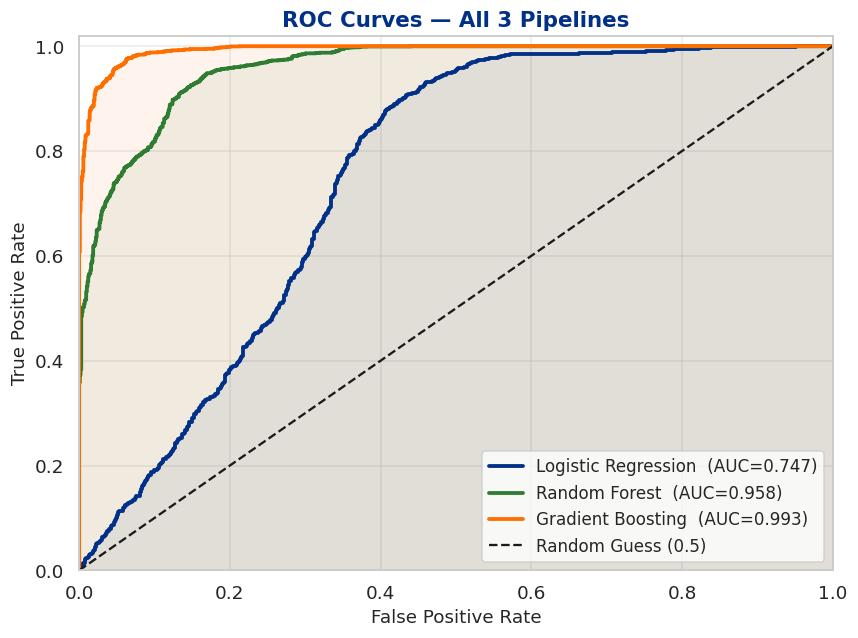

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
for fpr, tpr, auc_v, color, label in [
    (fpr_lr, tpr_lr, auc_lr, HDFC_BLUE,  'Logistic Regression'),
    (fpr_rf, tpr_rf, auc_rf, HDFC_GREEN, 'Random Forest'),
    (fpr_gb, tpr_gb, auc_gb, HDFC_ORG,   'Gradient Boosting')
]:
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{label}  (AUC={auc_v:.3f})')
    ax.fill_between(fpr, tpr, alpha=0.07, color=color)
ax.plot([0,1],[0,1],'k--',lw=1.5,label='Random Guess (0.5)')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate',fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All 3 Pipelines', fontsize=14, fontweight='bold', color=HDFC_BLUE)
ax.legend(loc='lower right', fontsize=11); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

---
##  Feature Importance — RF & GB

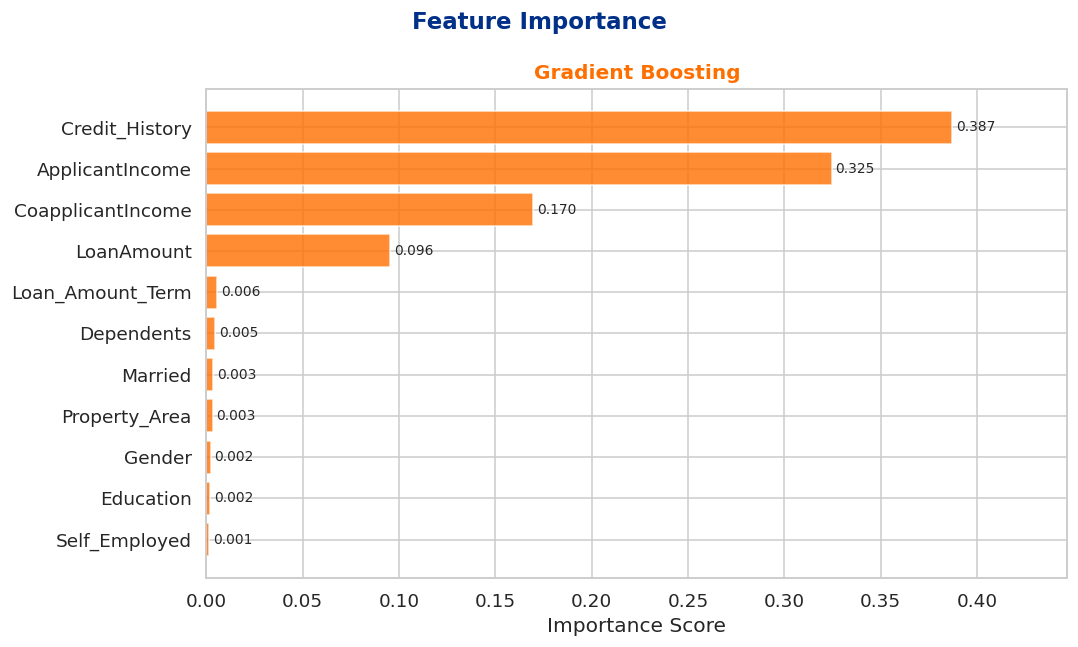

In [ ]:
feature_names = numerical_features + categorical_features
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Feature Importance', fontsize=15, fontweight='bold', color=HDFC_BLUE)

fi = pd.DataFrame({'Feature': feature_names,
                   'Importance': pipe_gb.named_steps['classifier'].feature_importances_})\
       .sort_values('Importance', ascending=True)
bars = ax.barh(fi['Feature'], fi['Importance'], color=HDFC_ORG, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, fi['Importance']):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_title('Gradient Boosting', fontweight='bold', color=HDFC_ORG)
ax.set_xlabel('Importance Score')
ax.set_xlim(0, fi['Importance'].max()+0.06)
plt.tight_layout(); plt.show()

---
#  Final Model Comparison


In [ ]:
results = pd.DataFrame({
    'Model'          : ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'CV Accuracy (%)': [round(cv_acc_lr.mean()*100,2), round(cv_acc_rf.mean()*100,2), round(cv_acc_gb.mean()*100,2)],
    'CV AUC'         : [round(cv_auc_lr.mean(),4),     round(cv_auc_rf.mean(),4),     round(cv_auc_gb.mean(),4)],
    'CV F1'          : [round(cv_f1_lr.mean(),4),      round(cv_f1_rf.mean(),4),      round(cv_f1_gb.mean(),4)],
    'Train AUC'      : [round(auc_lr,4),               round(auc_rf,4),               round(auc_gb,4)],
})

def style_col(s, higher_is_better=True):
    best = s.max() if higher_is_better else s.min()
    return ['background-color:#006400; font-weight:bold' if v==best else '' for v in s]

higher = ['CV Accuracy (%)','CV AUC','CV F1','Train AUC']

styled = results.set_index('Model').style
for col in higher:
    styled = styled.apply(lambda s: style_col(s, True),  subset=[col])
styled = styled.set_caption('📊 Model Comparison | 🟩 Green = Best ')
display(styled)

,CV Accuracy (%),CV AUC,CV F1,Train AUC
Model,,,,
Logistic Regression,81.370000,0.736900,0.880000,0.747400
Random Forest,88.260000,0.922500,0.919900,0.958300
Gradient Boosting,90.060000,0.931300,0.931000,0.992500


In [ ]:
best_idx = results['CV AUC'].idxmax()
best_row = results.iloc[best_idx]

print("FINAL VERDICT")
print("-"*40)
for _, row in results.iterrows():
    tag = '<-- BEST' if row['Model'] == best_row['Model'] else ''
    print(f"{row['Model']}: {row['CV Accuracy (%)']:.2f}% | AUC: {row['CV AUC']:.4f} {tag}")

print(f"\nBest Model  : {best_row['Model']}")
print(f"CV Accuracy : {best_row['CV Accuracy (%)']:.2f}%")
print(f"CV AUC      : {best_row['CV AUC']:.4f}")

FINAL VERDICT
----------------------------------------
Logistic Regression: 81.37% | AUC: 0.7369 
Random Forest: 88.26% | AUC: 0.9225 
Gradient Boosting: 90.06% | AUC: 0.9313 <-- BEST

Best Model  : Gradient Boosting
CV Accuracy : 90.06%
CV AUC      : 0.9313


In [ ]:
best_idx = results['CV AUC'].idxmax()
best_row = results.iloc[best_idx]
print('='*62)
print('  🏆  FINAL VERDICT')
print('='*62)
print(f"{'Model':<25}{'CV Acc':>9}{'CV AUC':>8}")
print('-'*62)
for _, row in results.iterrows():
    tag = '  ◄ BEST' if row['Model']==best_row['Model'] else ''
    print(f"{row['Model']:<25}{row['CV Accuracy (%)']:>8.2f}%{row['CV AUC']:>8.4f}")
print('='*62)
print(f"\n  Best Model  : {best_row['Model']}")
print(f"  CV Accuracy : {best_row['CV Accuracy (%)']:.2f}%")
print(f"  CV AUC      : {best_row['CV AUC']:.4f}")


  🏆  FINAL VERDICT
Model                       CV Acc  CV AUC
--------------------------------------------------------------
Logistic Regression         81.37%  0.7369
Random Forest               88.26%  0.9225
Gradient Boosting           90.06%  0.9313

  Best Model  : Gradient Boosting
  CV Accuracy : 90.06%
  CV AUC      : 0.9313


---
## Predict on Test Dataset


In [ ]:

predictions_df = pd.DataFrame({
    'Loan_ID'               : test_loan_ids.values,
    'LR_Prediction'         : pipe_lr.predict(X_test),
    'RF_Prediction'         : pipe_rf.predict(X_test),
    'GB_Prediction'         : pipe_gb.predict(X_test),
    'Final_Prediction_gb'   : pipe_gb.predict(X_test),
    'Final_Approval_Prob_gb': pipe_gb.predict_proba(X_test)[:,1].round(4)
})


predictions_df[['Loan_ID', 'Final_Prediction_gb', 'Final_Approval_Prob_gb']].to_csv('gb_predictions.csv', index=False)

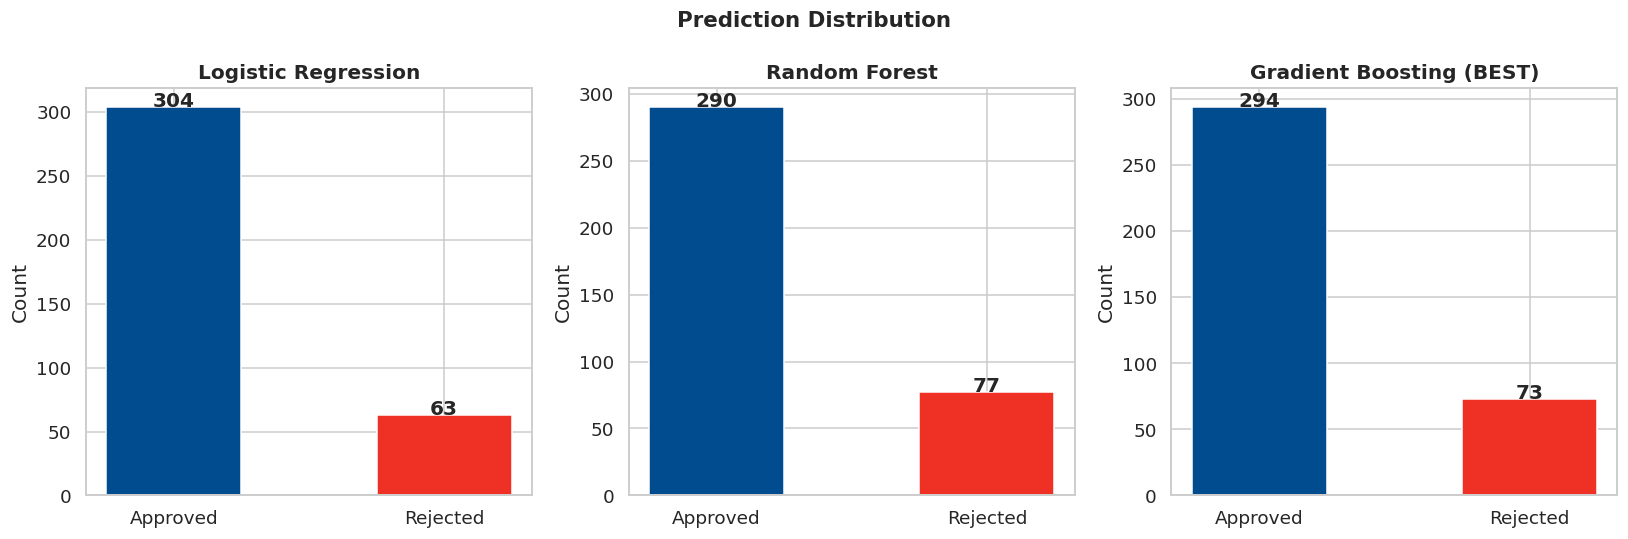

In [ ]:
HDFC_BLUE = '#004C8F'
HDFC_RED  = '#EE3124'

fig, axes = plt.subplots(1, 3, figsize=(15,5))
fig.suptitle('Prediction Distribution', fontsize=14, fontweight='bold')

for ax, col, title in [
    (axes[0], 'LR_Prediction', 'Logistic Regression'),
    (axes[1], 'RF_Prediction', 'Random Forest'),
    (axes[2], 'GB_Prediction', 'Gradient Boosting (BEST)')
]:
    counts = predictions_df[col].value_counts()
    lbls = ['Approved' if l==1 else 'Rejected' for l in counts.index]  # ✅ fixed
    bars = ax.bar(lbls, counts.values, color=[HDFC_BLUE, HDFC_RED], width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.3, str(val), ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()